<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/standards/technicalsafetyP0001.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )

# Litterature

[NORSOK S-001 Technical safety](https://handle.standard.no/en/webshop/ProductCatalog/ProductPresentation/?ProductID=1357800)

NORSOK S-001 is a Norwegian standard for technical safety in the petroleum industry. It provides requirements for the design, construction, and operation of offshore oil and gas production facilities, with the aim of ensuring the safety of personnel, the environment, and the facility itself.

The standard covers various aspects of technical safety, including fire protection, escape and evacuation systems, emergency response, and safety management. It also provides guidance on risk assessment and management, as well as the design and operation of safety-critical systems and equipment.

NORSOK S-001 is widely used in the Norwegian petroleum industry and is recognized as a key standard for ensuring the safety and integrity of offshore oil and gas production facilities.

# NORSOK S-001 technical-safety screening with NeqSim

This notebook turns the original standards note into a reproducible process-safety study. It is
written for process, technical-safety, and operations engineers who know basic thermodynamics.
Python experience is helpful but not required.

## Learning objectives

By the end, you can:

1. build and flash a realistic gas-condensate inventory with the SRK equation of state;
2. represent operating, trip, relief, design, and test pressure boundaries;
3. use NeqSim's native `S001SecondaryPressureProtectionCriteria`;
4. configure `VesselDepressurization` with geometry, material, orifice, and heat transfer;
5. quantify pressure, temperature, inventory, and flare-load histories;
6. compare blowdown-valve sizes and a pool-fire scenario; and
7. assemble evidence into a transparent screening decision.

The values are synthetic and public. This is training material, not a compliance assessment,
certification, relief-device datasheet, or substitute for the purchased standard.

In [2]:
import importlib.metadata
import json
import platform
import subprocess

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim import jneqsim


neqsim_version = importlib.metadata.version("neqsim")
java_version = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [neqsim_version, platform.python_version(), java_version],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 1. Engineering scope and assumptions

The case is an isolated high-pressure separator containing a single gas-rich equilibrium phase.
Emergency shutdown isolates incoming energy and mass. A blowdown valve then routes vapor to a
closed flare system. The study uses:

- SRK thermodynamics with the classic mixing rule;
- a perfectly mixed vessel;
- homogeneous vapor discharge through an orifice;
- a carbon-steel wall with transient one-dimensional conduction;
- 1.2 bara flare backpressure and 15 °C ambient air;
- synthetic pressure and reliability evidence.

Pressure is absolute throughout. Temperature is reported in °C and K. Mass flow is in kg/s.
Real projects must also address two-phase disengagement, acoustic fatigue, reaction forces,
dispersion, radiation, flare-network interaction, valve certification, brittle fracture,
instrument architecture, human factors, and all project-specific requirements.

In [3]:
operating_pressure_bara = 80.0
high_high_alarm_bara = 100.0
shutdown_trip_bara = 105.0
psv_set_pressure_bara = 110.0
design_pressure_bara = 120.0
maximum_event_pressure_bara = 125.0
test_pressure_bara = 180.0
flare_backpressure_bara = 1.2
blowdown_target_bara = 7.0
blowdown_target_time_s = 900.0

composition = {
    "nitrogen": 0.015,
    "CO2": 0.025,
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.040,
    "n-butane": 0.015,
    "n-pentane": 0.010,
}

composition_sum = sum(composition.values())
assert abs(composition_sum - 1.0) < 1.0e-12

pd.DataFrame(
    {
        "Component": list(composition),
        "Mole fraction [-]": list(composition.values()),
    }
)

Out[0]: 
   Component  Mole fraction [-]
0   nitrogen              0.015
1        CO2              0.025
2    methane              0.820
3     ethane              0.075
4    propane              0.040
5   n-butane              0.015
6  n-pentane              0.010


## 2. Pressure-boundary logic

A defensible pressure hierarchy keeps the normal operating point below protective actions and
the verified pressure boundary:

$$

p_{\mathrm{op}} < p_{\mathrm{HH}} < p_{\mathrm{trip}} < p_{\mathrm{PSV}}
\leq p_{\mathrm{design}} < p_{\mathrm{test}}

$$

Here $p$ is absolute pressure in bara. The maximum event pressure may exceed design pressure only
when the documented protection concept, applicable code, and test-pressure basis permit it. The
NeqSim S-001 helper used later performs a screening check; it does not replace a formal
independent-protection-layer or SIL verification.

In [4]:
fluid = jneqsim.thermo.system.SystemSrkEos(
    303.15,
    operating_pressure_bara,
)

for component_name, mole_fraction in composition.items():
    fluid.addComponent(component_name, mole_fraction)

fluid.setMixingRule("classic")
fluid.init(0)
fluid.init(1)
fluid.initPhysicalProperties()

feed_stream = jneqsim.process.equipment.stream.Stream(
    "HP separator inventory basis",
    fluid,
)
feed_stream.setTemperature(30.0, "C")
feed_stream.setPressure(operating_pressure_bara, "bara")
feed_stream.setFlowRate(1000.0, "kg/hr")
feed_stream.run()

phase_names = [
    str(feed_stream.getFluid().getPhase(index).getPhaseTypeName())
    for index in range(feed_stream.getFluid().getNumberOfPhases())
]
phase_names

Out[0]: ['gas']


### Why SRK and a NeqSim stream?

SRK is a transparent engineering choice for a hydrocarbon-rich gas over the pressure range used
here. NeqSim stores composition, state, phases, and real-fluid properties in the thermodynamic
system. The `Stream` makes that state composable with process equipment. A production model could
therefore connect the same stream to a separator, valve, compressor, or flare model.

The composition closure is

$$

\sum_i z_i = 1

$$

where $z_i$ is component $i$'s feed mole fraction. A project should compare SRK with an approved
property method and characterize heavier fractions when condensate behavior matters.

In [5]:
flashed_fluid = feed_stream.getFluid()

fluid_properties = pd.DataFrame(
    {
        "Quantity": [
            "Pressure",
            "Temperature",
            "Molar mass",
            "Density",
            "Compressibility factor",
            "Heat-capacity ratio",
            "Number of phases",
        ],
        "Value": [
            float(flashed_fluid.getPressure("bara")),
            float(flashed_fluid.getTemperature("C")),
            float(flashed_fluid.getMolarMass()) * 1000.0,
            float(flashed_fluid.getDensity("kg/m3")),
            float(flashed_fluid.getZ()),
            float(flashed_fluid.getGamma()),
            int(flashed_fluid.getNumberOfPhases()),
        ],
        "Unit": ["bara", "°C", "kg/kmol", "kg/m³", "-", "-", "-"],
    }
)

display(fluid_properties.round(4))

assert flashed_fluid.getNumberOfPhases() == 1
assert 0.5 < float(flashed_fluid.getZ()) < 1.2
assert float(flashed_fluid.getDensity("kg/m3")) > 20.0

,Quantity,Value,Unit
0,Pressure,80.0000,bara
1,Temperature,30.0000,°C
2,Molar mass,20.2882,kg/kmol
3,Density,79.3359,kg/m³
4,Compressibility factor,0.8158,-
5,Heat-capacity ratio,1.6767,-
6,Number of phases,1.0000,-


## 3. From process state to safeguards

The workflow below separates four questions:

1. **What is present?** NeqSim flashes the fluid and calculates inventory properties.
2. **What can challenge containment?** Pressure boundaries define alarm, trip, relief, and test
   levels.
3. **How does the system respond?** Native transient depressurization predicts pressure,
   temperature, mass, and discharge rate.
4. **Is the documented protection basis complete?** The S-001 screening helper checks supplied
   evidence fields.

This structure supports traceability: each safeguard has an input, a calculation, a result, and
an engineering owner.

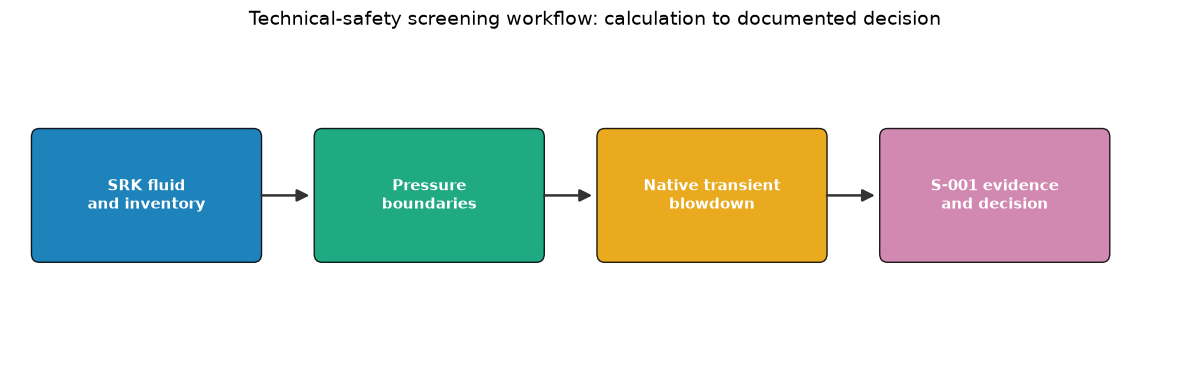

In [6]:
fig, axis = plt.subplots(figsize=(12, 3.8))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 3.0)
axis.axis("off")

workflow_nodes = [
    (0.3, "SRK fluid\nand inventory", "#0072B2"),
    (3.2, "Pressure\nboundaries", "#009E73"),
    (6.1, "Native transient\nblowdown", "#E69F00"),
    (9.0, "S-001 evidence\nand decision", "#CC79A7"),
]

for x_position, label, color in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, 1.0),
        2.2,
        1.1,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.88,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 1.1,
        1.55,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=11,
        weight="bold",
    )

for x_position in [2.55, 5.45, 8.35]:
    arrow = FancyArrowPatch(
        (x_position, 1.55),
        (x_position + 0.55, 1.55),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.8,
        color="#333333",
    )
    axis.add_patch(arrow)

axis.set_title(
    "Technical-safety screening workflow: calculation to documented decision",
    fontsize=14,
    pad=12,
)
plt.tight_layout()
plt.show()

The first figure is the reusable workflow overview. It prevents a common failure mode:
starting with a relief-device number before the fluid state, pressure basis, and acceptance
criteria have been made explicit.

## 4. Native NORSOK S-001 secondary-pressure-protection screen

NeqSim 3.16.0 exposes `S001SecondaryPressureProtectionCriteria`. The helper checks whether the
pressure basis, annual frequency target, relief-leakage routing evidence, and proof-test interval
are supplied and consistent. The example uses synthetic values; the standard itself remains the
authoritative source.

The frequency test has the form

$$

f_{\mathrm{demand}} \leq f_{\mathrm{target}}

$$

where both frequencies are annual demands per year. Passing this helper means the entered
screening fields are internally consistent, not that an entire safety function is compliant.

In [7]:
Criteria = (
    jneqsim.process.safety.processsafetysystem
    .S001SecondaryPressureProtectionCriteria
)


def evaluate_secondary_protection(
    demand_frequency_per_year,
    leakage_to_safe_location,
):
    criteria = Criteria()
    criteria.setMaximumEventPressureBara(maximum_event_pressure_bara)
    criteria.setDesignPressureBara(design_pressure_bara)
    criteria.setTestPressureBara(test_pressure_bara)
    criteria.setDemandFrequencyPerYear(demand_frequency_per_year)
    criteria.setReliefLeakageAssessed(True)
    criteria.setReliefLeakageToSafeLocation(
        leakage_to_safe_location
    )
    criteria.setProofTestIntervalMonths(6.0)
    raw_result = dict(criteria.evaluate().toMap())
    return {
        str(key): value
        for key, value in raw_result.items()
    }


screening_cases = {
    "Documented basis": evaluate_secondary_protection(
        1.0e-4,
        True,
    ),
    "Weak frequency and routing": evaluate_secondary_protection(
        5.0e-3,
        False,
    ),
}

screening_table = pd.DataFrame(screening_cases).T[
    [
        "maximumEventPressureBara",
        "designPressureBara",
        "testPressureBara",
        "demandFrequencyPerYear",
        "targetFrequencyPerYear",
        "pressureWithinTestPressure",
        "frequencyCriterionMet",
        "leakageRoutedSafe",
        "proofTestCriterionMet",
        "acceptable",
    ]
]
display(screening_table)

,maximumEventPressureBara,designPressureBara,testPressureBara,demandFrequencyPerYear,targetFrequencyPerYear,pressureWithinTestPressure,frequencyCriterionMet,leakageRoutedSafe,proofTestCriterionMet,acceptable
Documented basis,125.0,120.0,180.0,0.0001,0.001,True,True,True,True,True
Weak frequency and routing,125.0,120.0,180.0,0.005,0.001,True,False,False,True,False


The documented case passes because event pressure remains below test pressure, the
demand frequency is below the helper's resolved target, leakage is assessed and routed safely,
and the proof-test interval is within the supplied screening criterion. The deliberately weak
case fails for two independent reasons. Keeping failed cases is useful: it proves that the
screen is sensitive to missing or inadequate protection evidence.

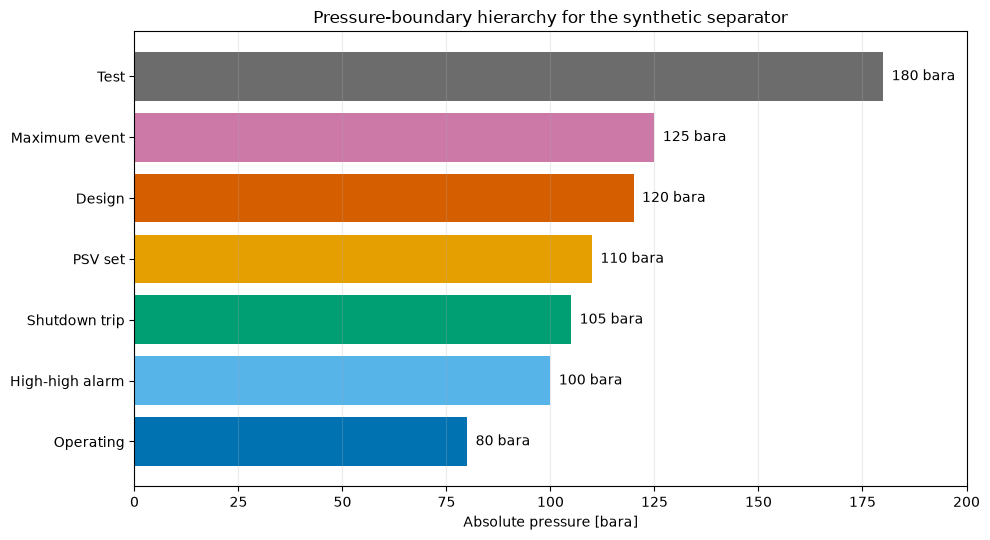

In [8]:
pressure_levels = pd.Series(
    {
        "Operating": operating_pressure_bara,
        "High-high alarm": high_high_alarm_bara,
        "Shutdown trip": shutdown_trip_bara,
        "PSV set": psv_set_pressure_bara,
        "Design": design_pressure_bara,
        "Maximum event": maximum_event_pressure_bara,
        "Test": test_pressure_bara,
    }
)

colors = [
    "#0072B2",
    "#56B4E9",
    "#009E73",
    "#E69F00",
    "#D55E00",
    "#CC79A7",
    "#6C6C6C",
]

fig, axis = plt.subplots(figsize=(10, 5.5))
bars = axis.barh(
    pressure_levels.index,
    pressure_levels.values,
    color=colors,
)
axis.set_xlabel("Absolute pressure [bara]")
axis.set_title("Pressure-boundary hierarchy for the synthetic separator")
axis.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, pressure_levels.values):
    axis.text(
        value + 2.0,
        bar.get_y() + bar.get_height() / 2.0,
        f"{value:.0f} bara",
        va="center",
    )

axis.set_xlim(0.0, 200.0)
plt.tight_layout()
plt.show()

The hierarchy plot makes the design intent auditable. Alarm and shutdown act before
the PSV set point; the maximum event pressure remains below test pressure. A real project must
derive these values from governing codes, vendor limits, relief scenarios, and approved
overpressure allowances rather than copying this example.

## 5. Dynamic vessel depressurization theory

For a well-mixed control volume with no inlet after isolation, the total mass balance is

$$

\frac{dm}{dt} = -\dot{m}_{\mathrm{out}}

$$

The energy-balance calculation uses

$$

\frac{dU}{dt} = \dot{Q} - \dot{m}_{\mathrm{out}} h_{\mathrm{out}}

$$

where $m$ is vessel inventory in kg, $U$ is internal energy in J, $\dot{Q}$ is wall-to-fluid heat
transfer in W, and $h_{\mathrm{out}}$ is discharge enthalpy in J/kg. NeqSim recomputes real-fluid
properties as pressure and temperature change.

For choked homogeneous gas flow, the leading dependence is

$$

\dot{m} \propto C_d A p
\sqrt{\frac{\gamma M}{ZRT}}

$$

where $C_d$ is discharge coefficient, $A$ is flow area in m², $\gamma$ is $C_p/C_v$, $M$ is
molar mass in kg/mol, $Z$ is compressibility, $R$ is the gas constant, $T$ is K, and $p$ is Pa.
The native equipment switches between choked and subcritical flow as backpressure becomes
important.

In [9]:
VesselDepressurization = (
    jneqsim.process.equipment.tank.VesselDepressurization
)


def create_blowdown_vessel(
    orifice_diameter_mm,
    fire_case=False,
):
    vessel = VesselDepressurization(
        f"HP separator {orifice_diameter_mm:.0f} mm BDV",
        feed_stream,
    )
    vessel.setVesselGeometry(
        12.0,
        2.0,
        VesselDepressurization.VesselOrientation.HORIZONTAL,
    )
    vessel.setVesselMaterial(
        0.025,
        VesselDepressurization.VesselMaterial.CARBON_STEEL,
    )
    vessel.setCalculationType(
        VesselDepressurization.CalculationType.ENERGY_BALANCE,
    )
    vessel.setHeatTransferType(
        VesselDepressurization.HeatTransferType.TRANSIENT_WALL,
    )
    vessel.setFlowDirection(
        VesselDepressurization.FlowDirection.DISCHARGE,
    )
    vessel.setOrificeDiameter(orifice_diameter_mm / 1000.0)
    vessel.setDischargeCoefficient(0.75)
    vessel.setBackPressure(flare_backpressure_bara)
    vessel.setAmbientTemperature(288.15)
    vessel.setCalculateExternalHTC(True)
    vessel.setTargetPressure(blowdown_target_bara)

    if fire_case:
        vessel.setFireType(
            VesselDepressurization.FireType.API_POOL
        )
        vessel.setWettedSurfaceFraction(1.0)

    vessel.run()
    return vessel

The factory function makes each scenario independent and reproducible. Geometry
determines both inventory volume and heat-transfer area. Carbon-steel properties and the
transient-wall model retain thermal inertia, so gas temperature and metal temperature need not
move together. The 35 mm base case is a screening bore, not a selected valve size.

In [10]:
base_vessel = create_blowdown_vessel(
    orifice_diameter_mm=35.0,
)

initial_inventory = pd.DataFrame(
    {
        "Quantity": [
            "Vessel volume",
            "Initial inventory",
            "Initial density",
            "Initial pressure",
            "Initial temperature",
            "BDV equivalent bore",
            "Flare backpressure",
        ],
        "Value": [
            float(base_vessel.getVolume()),
            float(base_vessel.getMass()),
            float(base_vessel.getDensity()),
            float(base_vessel.getPressure("bara")),
            float(base_vessel.getTemperature("C")),
            35.0,
            flare_backpressure_bara,
        ],
        "Unit": ["m³", "kg", "kg/m³", "bara", "°C", "mm", "bara"],
    }
)
display(initial_inventory.round(3))

,Quantity,Value,Unit
0,Vessel volume,41.888,m³
1,Initial inventory,3306.343,kg
2,Initial density,78.933,kg/m³
3,Initial pressure,80.000,bara
4,Initial temperature,30.000,°C
5,BDV equivalent bore,35.000,mm
6,Flare backpressure,1.200,bara


In [11]:
base_result = base_vessel.runSimulation(
    1800.0,
    2.0,
    1,
)


def result_frame(result):
    return pd.DataFrame(
        {
            "Time [s]": [
                float(value)
                for value in result.getTime()
            ],
            "Pressure [bara]": [
                float(value)
                for value in result.getPressure()
            ],
            "Gas temperature [°C]": [
                float(value) - 273.15
                for value in result.getTemperature()
            ],
            "Wall temperature [°C]": [
                float(value) - 273.15
                for value in result.getWallTemperature()
            ],
            "Inventory [kg]": [
                float(value)
                for value in result.getMass()
            ],
            "Discharge rate [kg/s]": [
                float(value)
                for value in result.getMassFlowRate()
            ],
        }
    )


base_history = result_frame(base_result)
base_history.tail()

Out[0]: 
     Time [s]  Pressure [bara]  ...  Inventory [kg]  Discharge rate [kg/s]
325     650.0         7.185587  ...      303.312313               1.113715
326     652.0         7.137162  ...      301.100729               1.105792
327     654.0         7.089050  ...      298.904881               1.097924
328     656.0         7.041247  ...      296.724660               1.090111
329     658.0         6.993753  ...      294.559956               1.082352

[5 rows x 6 columns]


## 6. Base-case results and checks

The pressure target is met when $p \leq 7$ bara. The time criterion used for this educational
case is

$$

t_{7\,\mathrm{bara}} \leq 900\ \mathrm{s}

$$

Gas temperature controls hydrate and low-temperature process risks, while wall temperature is
the relevant first screening variable for minimum-design-metal-temperature review. The model's
thermodynamic output is not a material qualification.

In [12]:
initial_mass_kg = base_history["Inventory [kg]"].iloc[0]
final_mass_kg = base_history["Inventory [kg]"].iloc[-1]
mass_discharged_kg = initial_mass_kg - final_mass_kg
reported_mass_discharged_kg = float(
    base_result.getMassDischarged()
)
mass_closure_relative = abs(
    mass_discharged_kg - reported_mass_discharged_kg
) / initial_mass_kg

base_summary = pd.DataFrame(
    {
        "Metric": [
            "Time to target",
            "Final pressure",
            "Peak discharge rate",
            "Minimum gas temperature",
            "Minimum wall temperature",
            "Mass discharged",
            "Mass closure error",
        ],
        "Value": [
            base_history["Time [s]"].iloc[-1],
            base_history["Pressure [bara]"].iloc[-1],
            base_history["Discharge rate [kg/s]"].max(),
            base_history["Gas temperature [°C]"].min(),
            base_history["Wall temperature [°C]"].min(),
            mass_discharged_kg,
            mass_closure_relative,
        ],
        "Unit": ["s", "bara", "kg/s", "°C", "°C", "kg", "-"],
    }
)
display(base_summary.round(4))

assert base_history["Pressure [bara]"].iloc[-1] <= 7.05
assert base_history["Time [s]"].iloc[-1] <= blowdown_target_time_s
assert mass_closure_relative < 1.0e-9
assert base_history["Inventory [kg]"].is_monotonic_decreasing
assert np.isfinite(base_history.to_numpy()).all()

,Metric,Value,Unit
0,Time to target,658.0000,s
1,Final pressure,6.9938,bara
2,Peak discharge rate,13.1939,kg/s
3,Minimum gas temperature,-23.8318,°C
4,Minimum wall temperature,8.1597,°C
5,Mass discharged,3011.7829,kg
6,Mass closure error,0.0000,-


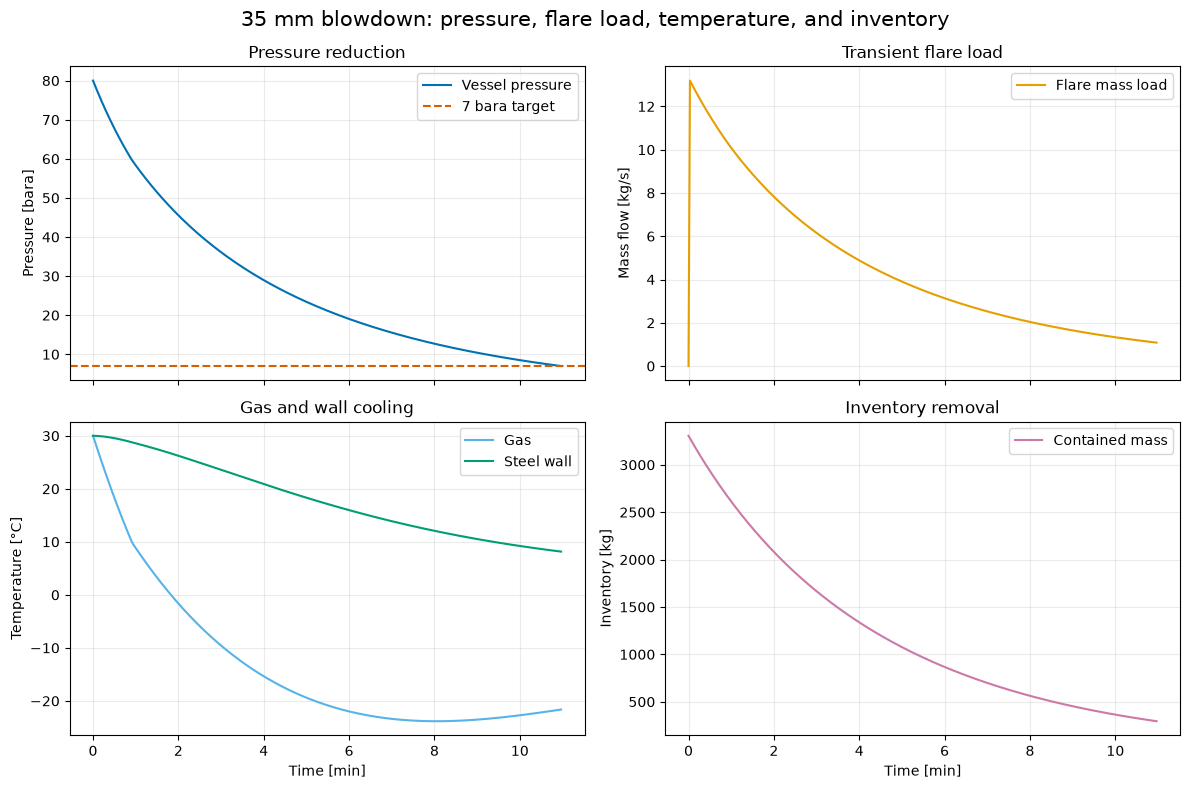

In [13]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
)

axes[0, 0].plot(
    base_history["Time [s]"] / 60.0,
    base_history["Pressure [bara]"],
    color="#0072B2",
    label="Vessel pressure",
)
axes[0, 0].axhline(
    blowdown_target_bara,
    color="#D55E00",
    linestyle="--",
    label="7 bara target",
)
axes[0, 0].set_ylabel("Pressure [bara]")
axes[0, 0].set_title("Pressure reduction")
axes[0, 0].legend()

axes[0, 1].plot(
    base_history["Time [s]"] / 60.0,
    base_history["Discharge rate [kg/s]"],
    color="#E69F00",
    label="Flare mass load",
)
axes[0, 1].set_ylabel("Mass flow [kg/s]")
axes[0, 1].set_title("Transient flare load")
axes[0, 1].legend()

axes[1, 0].plot(
    base_history["Time [s]"] / 60.0,
    base_history["Gas temperature [°C]"],
    color="#56B4E9",
    label="Gas",
)
axes[1, 0].plot(
    base_history["Time [s]"] / 60.0,
    base_history["Wall temperature [°C]"],
    color="#009E73",
    label="Steel wall",
)
axes[1, 0].set_xlabel("Time [min]")
axes[1, 0].set_ylabel("Temperature [°C]")
axes[1, 0].set_title("Gas and wall cooling")
axes[1, 0].legend()

axes[1, 1].plot(
    base_history["Time [s]"] / 60.0,
    base_history["Inventory [kg]"],
    color="#CC79A7",
    label="Contained mass",
)
axes[1, 1].set_xlabel("Time [min]")
axes[1, 1].set_ylabel("Inventory [kg]")
axes[1, 1].set_title("Inventory removal")
axes[1, 1].legend()

for axis in axes.flat:
    axis.grid(alpha=0.25)

fig.suptitle(
    "35 mm blowdown: pressure, flare load, temperature, and inventory",
    fontsize=15,
)
plt.tight_layout()
plt.show()

The principal result plot shows why a single blowdown time is insufficient. The
largest flare load occurs early, gas cools much faster than the steel wall, and most inventory
leaves before the pressure asymptotically approaches backpressure. Those outputs feed different
engineering owners: flare-network design, flow assurance, materials, and emergency response.

## 7. Blowdown-orifice sensitivity

Increasing bore area accelerates depressurization but raises peak flare load and can deepen
short-term gas cooling. Four independent NeqSim vessels are run from the same initial state. A
fresh object for each case prevents hidden state from contaminating the comparison.

In [14]:
def simulate_blowdown_case(
    orifice_diameter_mm,
    fire_case=False,
):
    vessel = create_blowdown_vessel(
        orifice_diameter_mm=orifice_diameter_mm,
        fire_case=fire_case,
    )
    result = vessel.runSimulation(
        1800.0,
        2.0,
        1,
    )
    history = result_frame(result)
    return vessel, result, history


sensitivity_histories = {}
sensitivity_rows = []

for orifice_diameter_mm in [25.0, 30.0, 35.0, 40.0]:
    case_vessel, case_result, case_history = simulate_blowdown_case(
        orifice_diameter_mm,
    )
    sensitivity_histories[orifice_diameter_mm] = case_history
    sensitivity_rows.append(
        {
            "BDV bore [mm]": orifice_diameter_mm,
            "Time to 7 bara [s]": case_history["Time [s]"].iloc[-1],
            "Peak rate [kg/s]": (
                case_history["Discharge rate [kg/s]"].max()
            ),
            "Minimum gas T [°C]": (
                case_history["Gas temperature [°C]"].min()
            ),
            "Minimum wall T [°C]": (
                case_history["Wall temperature [°C]"].min()
            ),
            "Mass discharged [%]": (
                100.0
                * (
                    case_history["Inventory [kg]"].iloc[0]
                    - case_history["Inventory [kg]"].iloc[-1]
                )
                / case_history["Inventory [kg]"].iloc[0]
            ),
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table.round(3))

assert sensitivity_table["Time to 7 bara [s]"].is_monotonic_decreasing
assert sensitivity_table["Peak rate [kg/s]"].is_monotonic_increasing
assert (
    sensitivity_table["Time to 7 bara [s]"].iloc[-1]
    < blowdown_target_time_s
)

,BDV bore [mm],Time to 7 bara [s],Peak rate [kg/s],Minimum gas T [°C],Minimum wall T [°C],Mass discharged [%]
0,25.0,1296.0,6.732,-15.284,3.284,91.465
1,30.0,900.0,9.693,-19.388,5.752,91.328
2,35.0,658.0,13.194,-23.832,8.160,91.091
3,40.0,502.0,17.233,-28.272,10.353,90.890


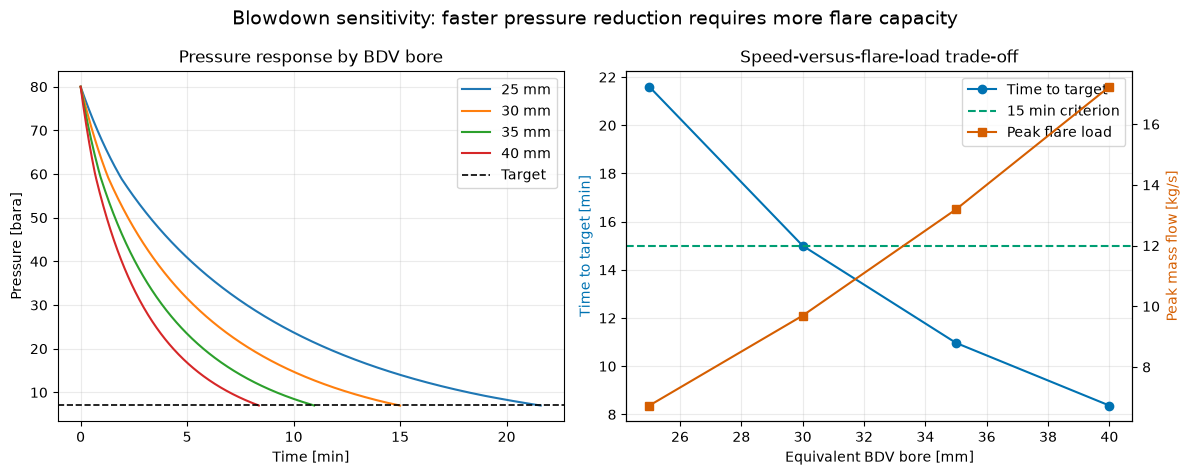

In [15]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)

for orifice_diameter_mm, history in sensitivity_histories.items():
    axes[0].plot(
        history["Time [s]"] / 60.0,
        history["Pressure [bara]"],
        label=f"{orifice_diameter_mm:.0f} mm",
    )

axes[0].axhline(
    blowdown_target_bara,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Target",
)
axes[0].set_xlabel("Time [min]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].set_title("Pressure response by BDV bore")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    sensitivity_table["BDV bore [mm]"],
    sensitivity_table["Time to 7 bara [s]"] / 60.0,
    marker="o",
    color="#0072B2",
    label="Time to target",
)
second_axis = axes[1].twinx()
second_axis.plot(
    sensitivity_table["BDV bore [mm]"],
    sensitivity_table["Peak rate [kg/s]"],
    marker="s",
    color="#D55E00",
    label="Peak flare load",
)
axes[1].axhline(
    blowdown_target_time_s / 60.0,
    color="#009E73",
    linestyle="--",
    label="15 min criterion",
)
axes[1].set_xlabel("Equivalent BDV bore [mm]")
axes[1].set_ylabel("Time to target [min]", color="#0072B2")
second_axis.set_ylabel("Peak mass flow [kg/s]", color="#D55E00")
axes[1].set_title("Speed-versus-flare-load trade-off")
axes[1].grid(alpha=0.25)

lines_1, labels_1 = axes[1].get_legend_handles_labels()
lines_2, labels_2 = second_axis.get_legend_handles_labels()
axes[1].legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
)

fig.suptitle(
    "Blowdown sensitivity: faster pressure reduction requires more flare capacity",
    fontsize=14,
)
plt.tight_layout()
plt.show()

The sensitivity plot is a design decision aid. A larger equivalent bore meets the
time target with more margin, but peak mass load increases. Selecting a valve therefore requires
simultaneous checks of vessel pressure, flare header capacity, acoustic fatigue, reaction load,
minimum temperature, and valve performance. The equivalent bore is not a vendor valve size.

## 8. Practical application: normal blowdown versus an API pool-fire preset

The final application adds NeqSim's native `API_POOL` fire preset to the same isolated vessel.
The fire model applies incident heat at the outer wall and conducts it inward through the
transient wall. This is a screening scenario for comparing trends, not a project fire-load
definition.

In [16]:
fire_vessel, fire_result, fire_history = simulate_blowdown_case(
    orifice_diameter_mm=35.0,
    fire_case=True,
)

scenario_table = pd.DataFrame(
    [
        {
            "Scenario": "No external fire",
            "Time to target [s]": base_history["Time [s]"].iloc[-1],
            "Peak rate [kg/s]": (
                base_history["Discharge rate [kg/s]"].max()
            ),
            "Minimum gas T [°C]": (
                base_history["Gas temperature [°C]"].min()
            ),
            "Maximum wall T [°C]": (
                base_history["Wall temperature [°C]"].max()
            ),
        },
        {
            "Scenario": "API pool-fire preset",
            "Time to target [s]": fire_history["Time [s]"].iloc[-1],
            "Peak rate [kg/s]": (
                fire_history["Discharge rate [kg/s]"].max()
            ),
            "Minimum gas T [°C]": (
                fire_history["Gas temperature [°C]"].min()
            ),
            "Maximum wall T [°C]": (
                fire_history["Wall temperature [°C]"].max()
            ),
        },
    ]
)
display(scenario_table.round(3))

assert np.isfinite(fire_history.to_numpy()).all()
assert fire_history["Pressure [bara]"].iloc[-1] <= 7.05
assert (
    fire_history["Wall temperature [°C]"].max()
    >= base_history["Wall temperature [°C]"].max()
)

,Scenario,Time to target [s],Peak rate [kg/s],Minimum gas T [°C],Maximum wall T [°C]
0,No external fire,658.0,13.194,-23.832,30.00
1,API pool-fire preset,730.0,13.194,4.680,256.61


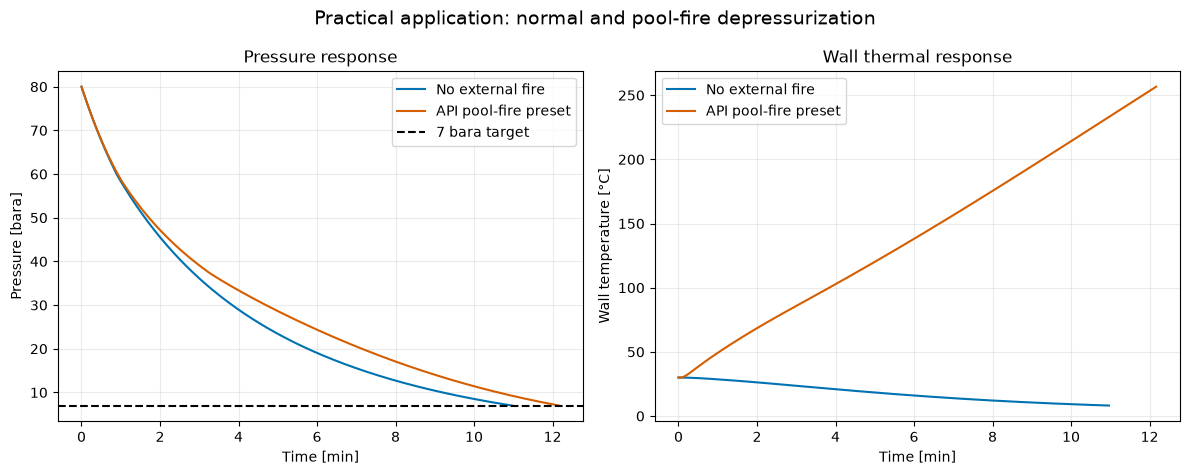

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)

for history, label, color in [
    (base_history, "No external fire", "#0072B2"),
    (fire_history, "API pool-fire preset", "#D55E00"),
]:
    axes[0].plot(
        history["Time [s]"] / 60.0,
        history["Pressure [bara]"],
        label=label,
        color=color,
    )
    axes[1].plot(
        history["Time [s]"] / 60.0,
        history["Wall temperature [°C]"],
        label=label,
        color=color,
    )

axes[0].axhline(
    blowdown_target_bara,
    color="black",
    linestyle="--",
    label="7 bara target",
)
axes[0].set_xlabel("Time [min]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].set_title("Pressure response")

axes[1].set_xlabel("Time [min]")
axes[1].set_ylabel("Wall temperature [°C]")
axes[1].set_title("Wall thermal response")

for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle(
    "Practical application: normal and pool-fire depressurization",
    fontsize=14,
)
plt.tight_layout()
plt.show()

The fire comparison demonstrates model composition: the same flashed stream and
vessel geometry are reused, while the external boundary condition changes. The pressure and
metal-temperature responses must be reviewed together. A detailed fire case also needs
validated heat flux, insulation behavior, wetted area, fire duration, passive protection, and
structural acceptance criteria.

## 9. Integrated screening decision

The final table connects the thermodynamic and dynamic calculation to explicit decision gates:

- secondary-pressure-protection evidence;
- pressure hierarchy;
- blowdown time;
- flare peak-load capacity;
- mass conservation;
- minimum wall-temperature screening.

The assumed 16 kg/s flare capacity and −29 °C carbon-steel screening temperature are synthetic
teaching limits. They must be replaced by approved project values.

In [18]:
assumed_flare_capacity_kg_s = 16.0
carbon_steel_screening_temperature_C = -29.0
documented_screen = screening_cases["Documented basis"]
base_peak_rate_kg_s = base_history["Discharge rate [kg/s]"].max()
minimum_wall_temperature_C = base_history[
    "Wall temperature [°C]"
].min()

decision_rows = [
    {
        "Gate": "S-001 evidence fields",
        "Observed": bool(documented_screen["acceptable"]),
        "Criterion": "NeqSim screen acceptable",
        "Pass": bool(documented_screen["acceptable"]),
    },
    {
        "Gate": "Pressure hierarchy",
        "Observed": maximum_event_pressure_bara,
        "Criterion": f"≤ {test_pressure_bara:.0f} bara test pressure",
        "Pass": maximum_event_pressure_bara <= test_pressure_bara,
    },
    {
        "Gate": "Blowdown time",
        "Observed": base_history["Time [s]"].iloc[-1],
        "Criterion": f"≤ {blowdown_target_time_s:.0f} s",
        "Pass": (
            base_history["Time [s]"].iloc[-1]
            <= blowdown_target_time_s
        ),
    },
    {
        "Gate": "Peak flare load",
        "Observed": base_peak_rate_kg_s,
        "Criterion": (
            f"≤ {assumed_flare_capacity_kg_s:.1f} kg/s"
        ),
        "Pass": base_peak_rate_kg_s <= assumed_flare_capacity_kg_s,
    },
    {
        "Gate": "Mass closure",
        "Observed": mass_closure_relative,
        "Criterion": "< 1e-9 relative",
        "Pass": mass_closure_relative < 1.0e-9,
    },
    {
        "Gate": "Minimum wall temperature",
        "Observed": minimum_wall_temperature_C,
        "Criterion": (
            f"≥ {carbon_steel_screening_temperature_C:.0f} °C"
        ),
        "Pass": (
            minimum_wall_temperature_C
            >= carbon_steel_screening_temperature_C
        ),
    },
]

decision_table = pd.DataFrame(decision_rows)
display(decision_table)

assert decision_table["Pass"].all()

,Gate,Observed,Criterion,Pass
0,S-001 evidence fields,True,NeqSim screen acceptable,True
1,Pressure hierarchy,125.0,≤ 180 bara test pressure,True
2,Blowdown time,658.0,≤ 900 s,True
3,Peak flare load,13.193892,≤ 16.0 kg/s,True
4,Mass closure,0.0,< 1e-9 relative,True
5,Minimum wall temperature,8.159739,≥ -29 °C,True


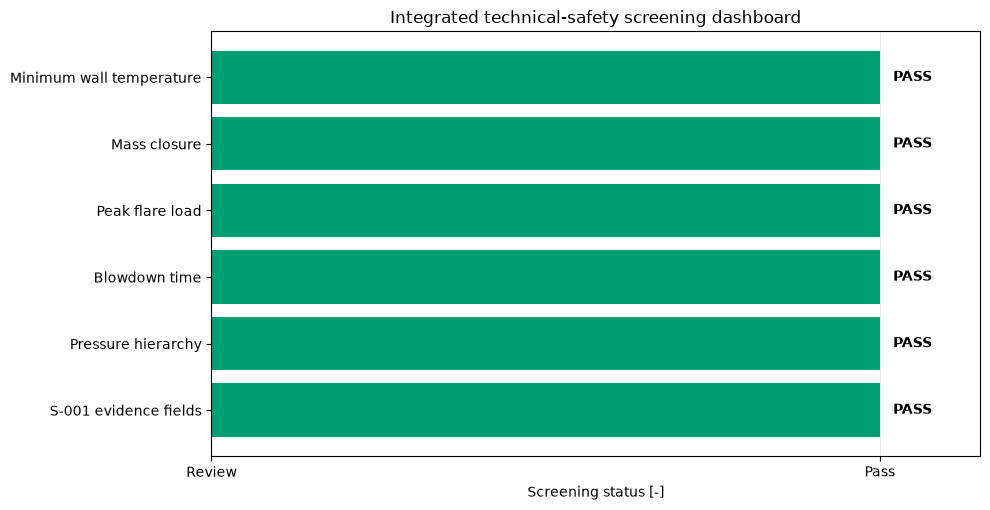

In [19]:
fig, axis = plt.subplots(figsize=(10, 5.2))

gate_labels = decision_table["Gate"].tolist()
gate_values = decision_table["Pass"].astype(int).to_numpy()
gate_colors = [
    "#009E73" if passed else "#D55E00"
    for passed in decision_table["Pass"]
]

axis.barh(
    gate_labels,
    gate_values,
    color=gate_colors,
)
axis.set_xlim(0.0, 1.15)
axis.set_xticks([0.0, 1.0], labels=["Review", "Pass"])
axis.set_xlabel("Screening status [-]")
axis.set_title(
    "Integrated technical-safety screening dashboard"
)
axis.grid(axis="x", alpha=0.25)

for row_index, passed in enumerate(decision_table["Pass"]):
    axis.text(
        1.02,
        row_index,
        "PASS" if passed else "REVIEW",
        va="center",
        weight="bold",
    )

plt.tight_layout()
plt.show()

All synthetic gates pass for the 35 mm base case. This means the example is
self-consistent under its stated assumptions. It does **not** mean the facility is safe or
compliant. Technical safety is a lifecycle activity: assumptions, calculations, barrier status,
test evidence, overrides, impairments, and management of change all require controlled records.

In [20]:
engineering_checks = {
    "composition_closes": abs(composition_sum - 1.0) < 1.0e-12,
    "single_phase_initial_state": (
        flashed_fluid.getNumberOfPhases() == 1
    ),
    "finite_initial_properties": np.isfinite(
        fluid_properties["Value"].astype(float)
    ).all(),
    "alarm_above_operation": (
        high_high_alarm_bara > operating_pressure_bara
    ),
    "trip_above_alarm": (
        shutdown_trip_bara > high_high_alarm_bara
    ),
    "psv_above_trip": (
        psv_set_pressure_bara > shutdown_trip_bara
    ),
    "design_at_or_above_psv": (
        design_pressure_bara >= psv_set_pressure_bara
    ),
    "event_below_test": (
        maximum_event_pressure_bara <= test_pressure_bara
    ),
    "s001_positive_case_passes": bool(
        screening_cases["Documented basis"]["acceptable"]
    ),
    "s001_negative_case_fails": not bool(
        screening_cases["Weak frequency and routing"]["acceptable"]
    ),
    "base_target_reached": (
        base_history["Pressure [bara]"].iloc[-1] <= 7.05
    ),
    "base_time_passes": (
        base_history["Time [s]"].iloc[-1]
        <= blowdown_target_time_s
    ),
    "mass_closure_passes": mass_closure_relative < 1.0e-9,
    "inventory_decreases": (
        base_history["Inventory [kg]"].is_monotonic_decreasing
    ),
    "sensitivity_time_monotonic": (
        sensitivity_table["Time to 7 bara [s]"]
        .is_monotonic_decreasing
    ),
    "sensitivity_peak_monotonic": (
        sensitivity_table["Peak rate [kg/s]"]
        .is_monotonic_increasing
    ),
    "fire_case_target_reached": (
        fire_history["Pressure [bara]"].iloc[-1] <= 7.05
    ),
    "fire_heats_wall": (
        fire_history["Wall temperature [°C]"].max()
        >= base_history["Wall temperature [°C]"].max()
    ),
    "all_histories_finite": (
        np.isfinite(base_history.to_numpy()).all()
        and np.isfinite(fire_history.to_numpy()).all()
    ),
    "integrated_decision_passes": decision_table["Pass"].all(),
}

failed_checks = [
    name
    for name, passed in engineering_checks.items()
    if not passed
]
assert not failed_checks, failed_checks

validation_table = pd.DataFrame(
    {
        "Engineering check": list(engineering_checks),
        "Passed": list(engineering_checks.values()),
    }
)
display(validation_table)
print(
    f"All {len(engineering_checks)} engineering checks passed."
)

All 20 engineering checks passed.


,Engineering check,Passed
0,composition_closes,True
1,single_phase_initial_state,True
2,finite_initial_properties,True
3,alarm_above_operation,True
4,trip_above_alarm,True
5,psv_above_trip,True
6,design_at_or_above_psv,True
7,event_below_test,True
8,s001_positive_case_passes,True
9,s001_negative_case_fails,True


## 10. Troubleshooting and validity limits

### Common issues

- **No discharge:** confirm upstream pressure is above flare backpressure and the orifice diameter
  is in metres when passed to NeqSim.
- **NaN thermodynamics:** do not create a zero-mole fluid; normalize composition and flash the
  stream before constructing the vessel.
- **Unexpected runtime:** use a stable time step, create a fresh vessel for each scenario, and
  retain a converged initial state.
- **Temperature confusion:** NeqSim's native temperature histories are K; this notebook converts
  them to °C only for reporting.
- **Pressure confusion:** the API accepts bar/bara for the configuration calls used here; plots
  explicitly report bara.

### Model limits

The vessel is perfectly mixed, the discharge is homogeneous, and the fire case is a prescribed
preset. The calculation does not model a full flare network, reactive chemistry, structural
failure, detailed liquid carryover, dispersion, escalation, or human response. Validate the
property model and transient formulation against approved methods before design use.

In [21]:
reusable_case_summary = {
    "topic": "NORSOK S-001 technical-safety screening",
    "neqsim_version": neqsim_version,
    "thermodynamic_model": "SRK with classic mixing rule",
    "operating_pressure_bara": operating_pressure_bara,
    "vessel_volume_m3": float(base_vessel.getVolume()),
    "initial_inventory_kg": initial_mass_kg,
    "bdv_equivalent_bore_mm": 35.0,
    "time_to_7_bara_s": float(
        base_history["Time [s]"].iloc[-1]
    ),
    "peak_flare_load_kg_s": float(base_peak_rate_kg_s),
    "minimum_gas_temperature_C": float(
        base_history["Gas temperature [°C]"].min()
    ),
    "minimum_wall_temperature_C": float(
        minimum_wall_temperature_C
    ),
    "s001_screen_acceptable": bool(
        documented_screen["acceptable"]
    ),
    "engineering_checks_passed": len(engineering_checks),
}

print(json.dumps(reusable_case_summary, indent=2))

{
  "topic": "NORSOK S-001 technical-safety screening",
  "neqsim_version": "3.16.0",
  "thermodynamic_model": "SRK with classic mixing rule",
  "operating_pressure_bara": 80.0,
  "vessel_volume_m3": 41.88790204786391,
  "initial_inventory_kg": 3306.342807657119,
  "bdv_equivalent_bore_mm": 35.0,
  "time_to_7_bara_s": 658.0,
  "peak_flare_load_kg_s": 13.193892316264964,
  "minimum_gas_temperature_C": -23.83175481094628,
  "minimum_wall_temperature_C": 8.159739026067086,
  "s001_screen_acceptable": true,
  "engineering_checks_passed": 20
}


## 11. Summary, exercises, and references

This notebook preserved the original NORSOK S-001 introduction and upgraded its obsolete NeqSim
installation. It now demonstrates a real NeqSim workflow:

`SRK fluid → flashed stream → pressure hierarchy → S-001 evidence screen → native vessel
depressurization → orifice and fire sensitivities → integrated decision`

### Further exercises

1. Replace the synthetic composition with an approved project fluid and compare SRK with PR.
2. Add a liquid-rich initial state and evaluate outlet liquid rainout and flare knockout needs.
3. Couple multiple simultaneous blowdowns to a flare-network pressure model.
4. Compare transient-wall, fixed-$U$, and adiabatic heat-transfer assumptions.
5. Replace screening limits with controlled project data and record each source.
6. Add fire-and-gas detection, ESD, and proof-test evidence to a complete barrier register.

### Authoritative and implementation references

- [NORSOK S-001 Technical safety](https://handle.standard.no/en/webshop/ProductCatalog/ProductPresentation/?ProductID=1357800)
- [NeqSim vessel depressurization documentation](https://equinor.github.io/neqsim/process/equipment/vessel_depressurization.html)
- [NeqSim dynamic simulation guide](https://equinor.github.io/neqsim/simulation/dynamic_simulation_guide.html)
- [NeqSim `VesselDepressurization` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/tank/VesselDepressurization.java)
- [NeqSim S-001 screening source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/safety/processsafetysystem/S001SecondaryPressureProtectionCriteria.java)

Always consult the purchased current standards, governing regulations, project design basis, and
independent technical-safety specialists before applying these methods.